In [15]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path(".").resolve()))
sys.path.insert(0, str(Path("scripts").resolve()))
from leaderboard_utils import extract_pollutant, display_dataset
from compute_local_leaderboard import _iter_model_series

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})

In [16]:
# ── Configuration ──────────────────────────────────────────────────────
RESULTS_ROOT = Path("output/results")
HORIZON      = "short"    # short | medium | long
METRIC       = "MASE"     # primary metric
THRESHOLD    = 50         # exclude sites with mean MASE or CRPS above this
MODELS       = ["seasonal_naive", "visiontspp_base", "patchtst"]
MODELS       = ["visiontspp_base"]

def discover_datasets(results_root: Path, reference_model: str) -> list[str]:
    base = results_root / reference_model
    if not base.exists():
        return []
    datasets = []
    for ds_dir in sorted(base.iterdir()):
        if not ds_dir.is_dir():
            continue
        for freq_dir in sorted(ds_dir.iterdir()):
            if freq_dir.is_dir():
                datasets.append(f"{ds_dir.name}/{freq_dir.name}")
    return datasets


DATASETS = discover_datasets(RESULTS_ROOT, MODELS[0])
print(f"Discovered {len(DATASETS)} datasets: {DATASETS}")

Discovered 7 datasets: ['AURN/H', 'CNEMC_SMALL/H', 'CPCB/H', 'EEA_DE/H', 'EEA_FR/H', 'EPA/H', 'SINAICA/H']


In [17]:
# ── Pre-compute excluded sites (all models, MASE+CRPS threshold) ──────────────
# A site is excluded for a (dataset_id, horizon) if its mean MASE > THRESHOLD
# OR mean CRPS > THRESHOLD across all models.

print("Computing site exclusions (scanning all models)...")
site_metric_values: dict[str, dict[tuple, list]] = {"MASE": {}, "CRPS": {}}

for model_name, dataset_id, horizon, item_ids, npz_metrics in _iter_model_series(RESULTS_ROOT):
    n_series = len(item_ids)
    for metric_name in ["MASE", "CRPS"]:
        arr = npz_metrics.get(metric_name)
        if arr is None or arr.shape[0] != n_series:
            continue
        reduce_axes = tuple(range(1, arr.ndim))
        per_series = np.nanmean(arr[:n_series], axis=reduce_axes) if reduce_axes else arr[:n_series]
        for i, iid in enumerate(item_ids):
            val = per_series[i]
            if not np.isnan(val):
                site_metric_values[metric_name].setdefault(
                    (dataset_id, horizon, iid), []
                ).append(float(val))

excluded_sites: dict[tuple, set] = {}
for key in set(site_metric_values["MASE"]) | set(site_metric_values["CRPS"]):
    dataset_id, horizon, iid = key
    mase_vals = site_metric_values["MASE"].get(key, [])
    crps_vals = site_metric_values["CRPS"].get(key, [])
    if (mase_vals and np.mean(mase_vals) > THRESHOLD) or \
       (crps_vals and np.mean(crps_vals) > THRESHOLD):
        excluded_sites.setdefault((dataset_id, horizon), set()).add(iid)

print(f"\nThreshold: mean MASE > {THRESHOLD} OR mean CRPS > {THRESHOLD} (across all models)\n")
if not excluded_sites:
    print("  No sites excluded.")
else:
    for (dataset_id, horizon), iids in sorted(excluded_sites.items()):
        pol_counts: dict[str, int] = {}
        for iid in iids:
            pol = extract_pollutant(iid)
            pol_counts[pol] = pol_counts.get(pol, 0) + 1
        breakdown = "  ".join(f"{pol}: {n}" for pol, n in sorted(pol_counts.items()))
        print(f"  {dataset_id}/{horizon}  —  {len(iids)} sites excluded")
        print(f"    by pollutant: {breakdown}")

Computing site exclusions (scanning all models)...

Threshold: mean MASE > 50 OR mean CRPS > 50 (across all models)

  CPCB/H/short  —  1 sites excluded
    by pollutant: CO: 1
  EEA_DE/H/short  —  22 sites excluded
    by pollutant: NO2: 2  SO2: 20
  EPA/H/short  —  55 sites excluded
    by pollutant: CO: 2  SO2: 53


In [ ]:
# ── Data loading helpers ────────────────────────────────────────────────

def load_model_data(results_root: Path, dataset_id: str, horizon: str, model: str):
    base         = results_root / model / dataset_id / horizon
    config_path  = base / "config.json"
    metrics_path = base / "metrics.npz"
    pred_path    = base / "predictions.npz"

    if not metrics_path.exists() or not config_path.exists():
        return None

    with open(config_path) as f:
        cfg = json.load(f)

    item_ids   = cfg["item_ids"]
    scale      = cfg.get("prediction_scale_factor", 1.0)
    pollutants = [extract_pollutant(iid) for iid in item_ids]

    npz_m   = np.load(metrics_path)
    # Arrays are (n_series, n_windows, n_variates=1); squeeze the variate dim
    metrics = {k: npz_m[k][:, :, 0] for k in npz_m.files}  # (n_series, n_windows)

    timestamps = None
    if pred_path.exists():
        npz_p = np.load(pred_path)
        if "timestamps" in npz_p:
            timestamps = pd.to_datetime(npz_p["timestamps"][0, :, 0], unit="s")

    return dict(
        metrics=metrics,
        timestamps=timestamps,
        item_ids=item_ids,
        pollutants=pollutants,
        scale=scale,
        cfg=cfg,
    )


def load_all_models(results_root, dataset_id, horizon, models, metric):
    data = {}
    for model in models:
        d = load_model_data(results_root, dataset_id, horizon, model)
        if d is None:
            continue
        if metric not in d["metrics"]:
            continue
        data[model] = d
    return data


def get_masked_mean(d, metric, pollutant, dataset_id, horizon, excluded_sites):
    """Return (n_windows,) mean across non-excluded sites for one pollutant/model."""
    pol_mask = np.array([p == pollutant for p in d["pollutants"]])
    if not pol_mask.any():
        return None
    arr = d["metrics"][metric][pol_mask].copy()          # (n_pol_sites, n_windows)
    exclude_ids = excluded_sites.get((dataset_id, horizon), set())
    pol_item_ids = [iid for iid, p in zip(d["item_ids"], d["pollutants"]) if p == pollutant]
    for i, iid in enumerate(pol_item_ids):
        if iid in exclude_ids:
            arr[i, :] = np.nan
    return np.nanmean(arr, axis=0)  # (n_windows,)

In [19]:
# ── Date ranges per dataset ───────────────────────────────────────────────────
print(f"{'Dataset':<20}  {'Start':^12}  {'End':^12}  {'Days':>5}  {'Windows':>7}")
print("-" * 62)
for dataset_id in DATASETS:
    for model in MODELS:
        d = load_model_data(RESULTS_ROOT, dataset_id, HORIZON, model)
        if d is not None and d["timestamps"] is not None:
            ts = d["timestamps"]
            start = ts.min().date()
            end   = ts.max().date()
            n_days = (end - start).days + 1
            print(f"{dataset_id:<20}  {str(start):^12}  {str(end):^12}  {n_days:>5}  {len(ts):>7}")
            break  # one model is enough for timestamps
    else:
        print(f"{dataset_id:<20}  {'—':^12}  {'—':^12}  {'—':>5}  {'—':>7}")

Dataset                  Start          End        Days  Windows
--------------------------------------------------------------
AURN/H                 2023-07-08    2025-06-30     724      724
CNEMC_SMALL/H          2023-07-08    2025-06-30     724      724
CPCB/H                 2023-07-08    2025-06-30     724      724
EEA_DE/H               2023-07-08    2025-06-30     724      724
EEA_FR/H               2023-07-08    2025-06-30     724      724
EPA/H                  2023-07-08    2025-06-30     724      724
SINAICA/H              2023-07-08    2025-06-30     724      724


In [20]:
# ── Calendar heatmap helpers ────────────────────────────────────────────

def make_calendar_grid(daily_series: pd.Series, year: int):
    """
    Build a (7, n_weeks) grid for a calendar heatmap of a single year.

    Row 0 = Monday, row 6 = Sunday.
    Column 0 is the ISO week that contains January 1st (starting on Monday).
    Returns: grid array, number of weeks, list of (week_idx, month_abbr) for x-tick labels.
    """
    jan1  = pd.Timestamp(year, 1, 1)
    start = jan1 - pd.Timedelta(days=jan1.weekday())   # Monday on/before Jan 1
    dec31 = pd.Timestamp(year, 12, 31)
    end   = dec31 + pd.Timedelta(days=6 - dec31.weekday())  # Sunday on/after Dec 31
    n_weeks = (end - start).days // 7 + 1

    grid = np.full((7, n_weeks), np.nan)
    for ts, val in daily_series.items():
        if ts.year == year and not np.isnan(val):
            offset = (ts - start).days
            if offset >= 0:
                row = offset % 7        # 0=Mon ... 6=Sun
                col = offset // 7
                if col < n_weeks:
                    grid[row, col] = val

    month_ticks = []
    for m in range(1, 13):
        ms = pd.Timestamp(year, m, 1)
        w  = (ms - start).days // 7
        if 0 <= w < n_weeks:
            month_ticks.append((w, ms.strftime("%b")))

    return grid, n_weeks, month_ticks


def plot_calendar_heatmap(
    daily_mase: pd.Series,
    dataset_id: str,
    model:      str,
    metric:     str = "MASE",
):
    """
    Calendar heatmap averaged over all pollutants — one horizontal year panel
    per year, stacked vertically.
    X-axis: weeks (month-labelled), Y-axis: day of week Mon→Sun.
    Color: light (low error) → red (high error).
    """
    years = sorted(daily_mase.index.year.unique())
    if not years:
        return
    valid = daily_mase.dropna().values
    if len(valid) == 0:
        return

    vmin  = 0.0
    vmax  = float(np.percentile(valid, 99))
    cmap  = "YlOrRd"

    n_years = len(years)
    fig, axes = plt.subplots(
        n_years, 1,
        figsize=(20, 2.2 * n_years + 0.8),
        gridspec_kw={"hspace": 0.7},
    )
    if n_years == 1:
        axes = [axes]

    im_ref = None
    for ax, year in zip(axes, years):
        grid, n_weeks, month_ticks = make_calendar_grid(daily_mase, year)

        im = ax.pcolormesh(
            np.arange(n_weeks + 1),   # x-boundaries (columns + 1)
            np.arange(8),              # y-boundaries (rows + 1)
            grid,                      # (7, n_weeks)
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolors="white",
            linewidth=0.5,
        )
        im_ref = im

        # Y-axis: Mon at top
        ax.set_yticks(np.arange(7) + 0.5)
        ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], fontsize=8)
        ax.invert_yaxis()

        # X-axis: month labels at week where each month starts
        tick_pos    = [w   for w, _   in month_ticks]
        tick_labels = [lbl for _, lbl in month_ticks]
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_labels, fontsize=9, ha="left")
        ax.tick_params(axis="x", length=0)
        ax.set_xlim(0, n_weeks)

        # Year label rotated 90° on the left side
        ax.set_ylabel(str(year), rotation=90, fontsize=10, labelpad=12, va="center")

        for spine in ax.spines.values():
            spine.set_visible(False)

    if im_ref is not None:
        fig.colorbar(
            im_ref, ax=axes,
            orientation="vertical",
            label=metric,
            fraction=0.015,
            pad=0.02,
        )

    fig.suptitle(
        f"{display_dataset(dataset_id)} — {model}  (avg over pollutants)\n"
        f"({metric} per day, nanmean across sites & pollutants  |  {HORIZON} horizon  |  "
        f"sites with mean MASE or CRPS > {THRESHOLD} excluded)",
        fontsize=12,
        y=1.01,
    )
    plt.show()

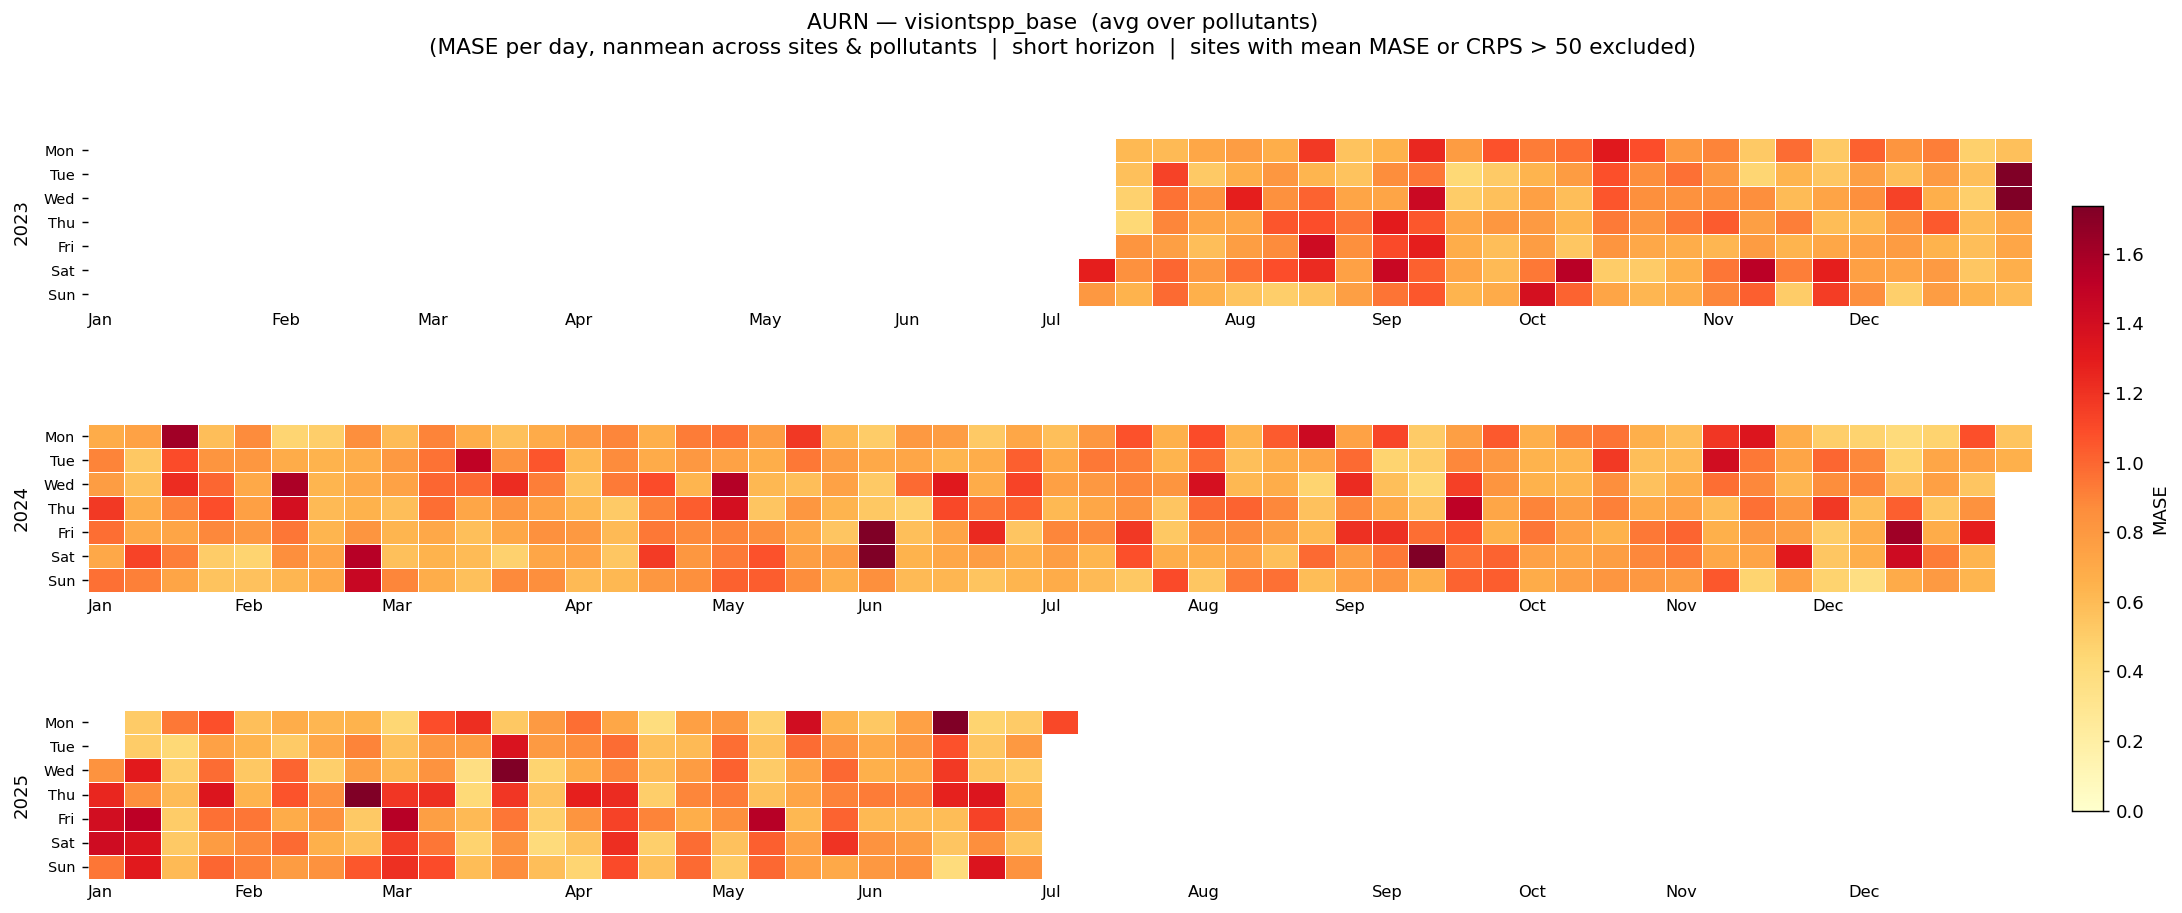

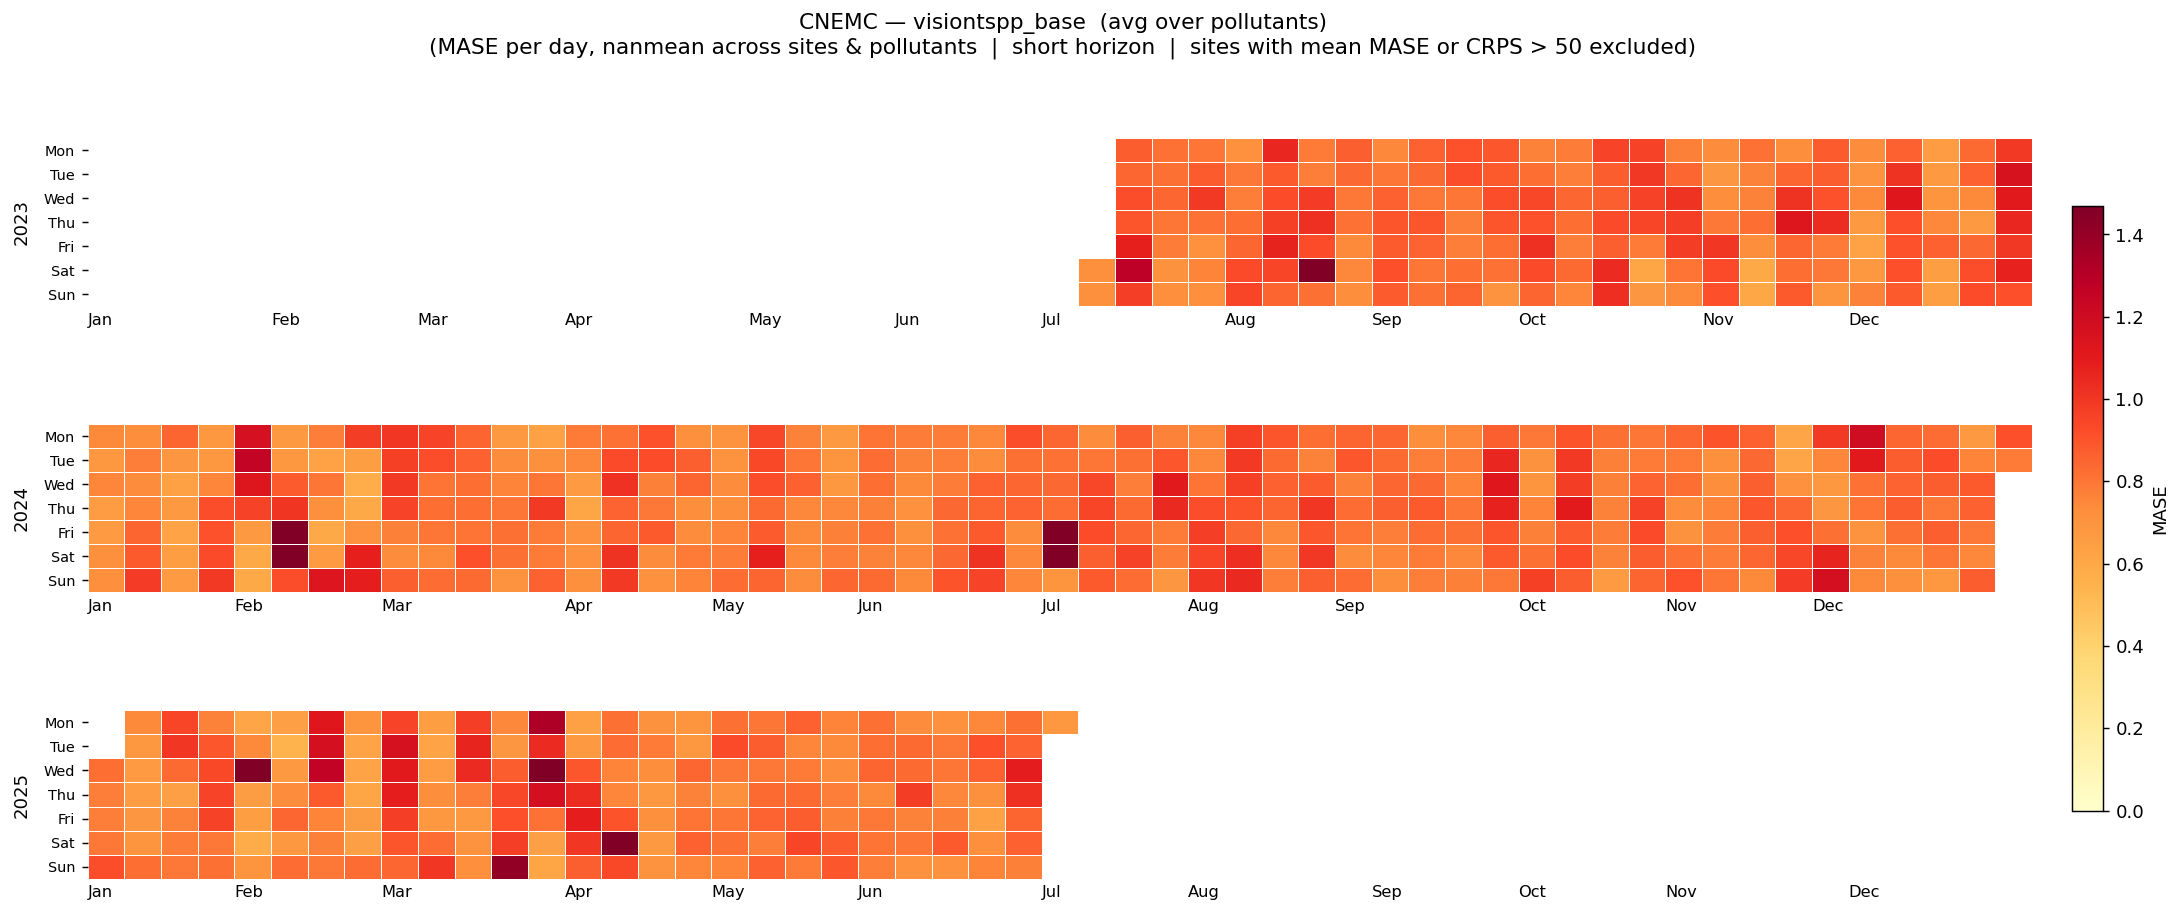

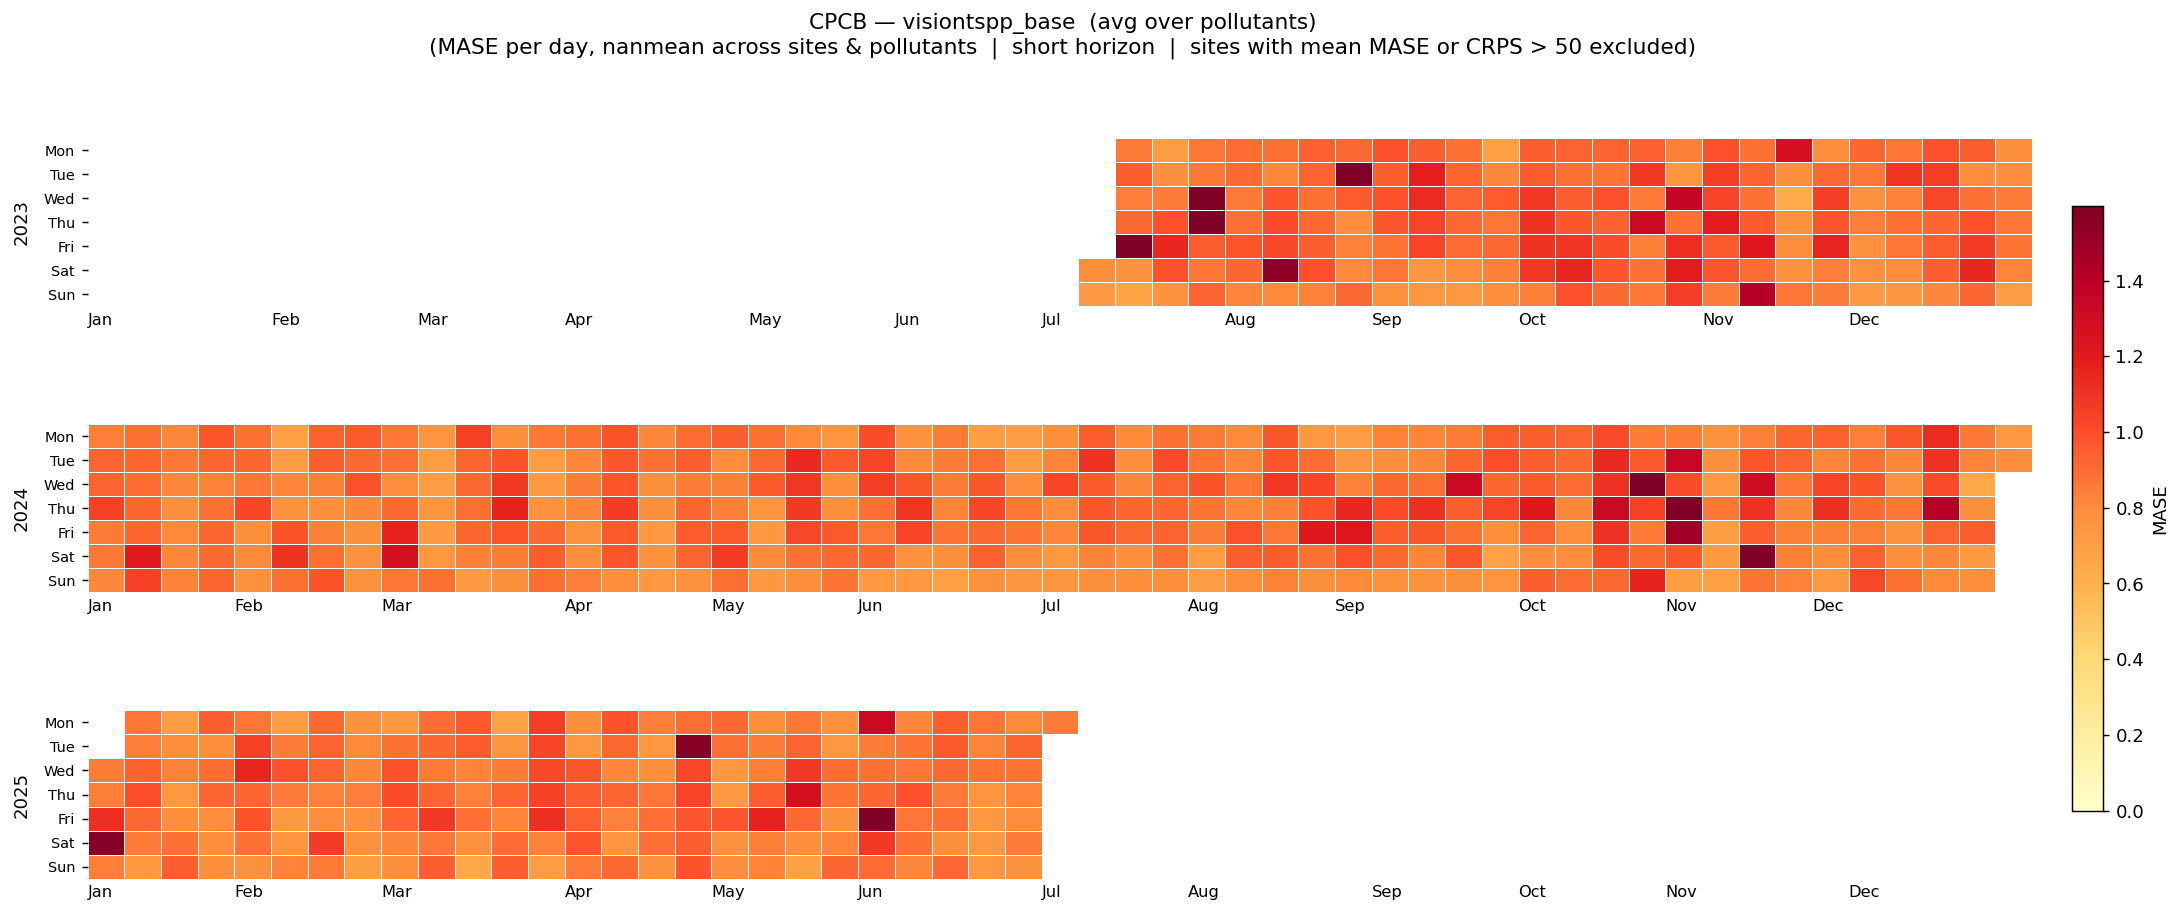

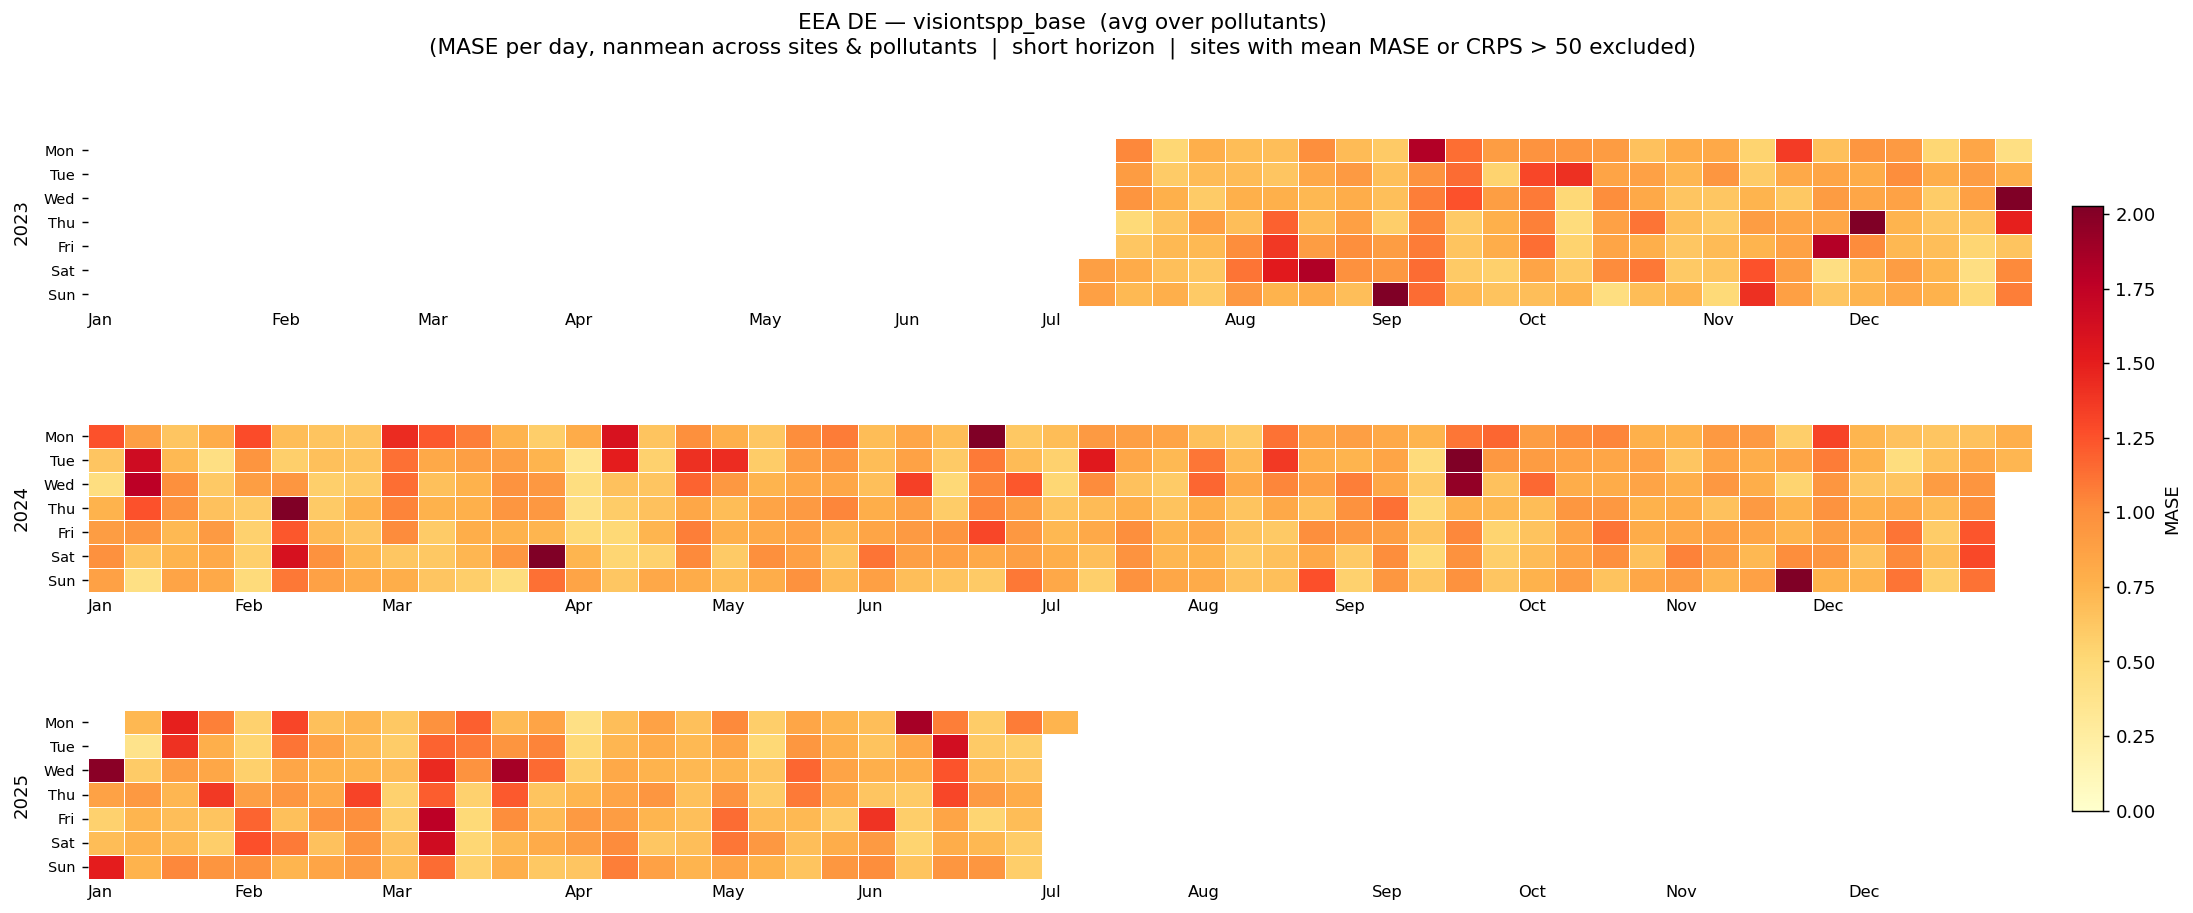

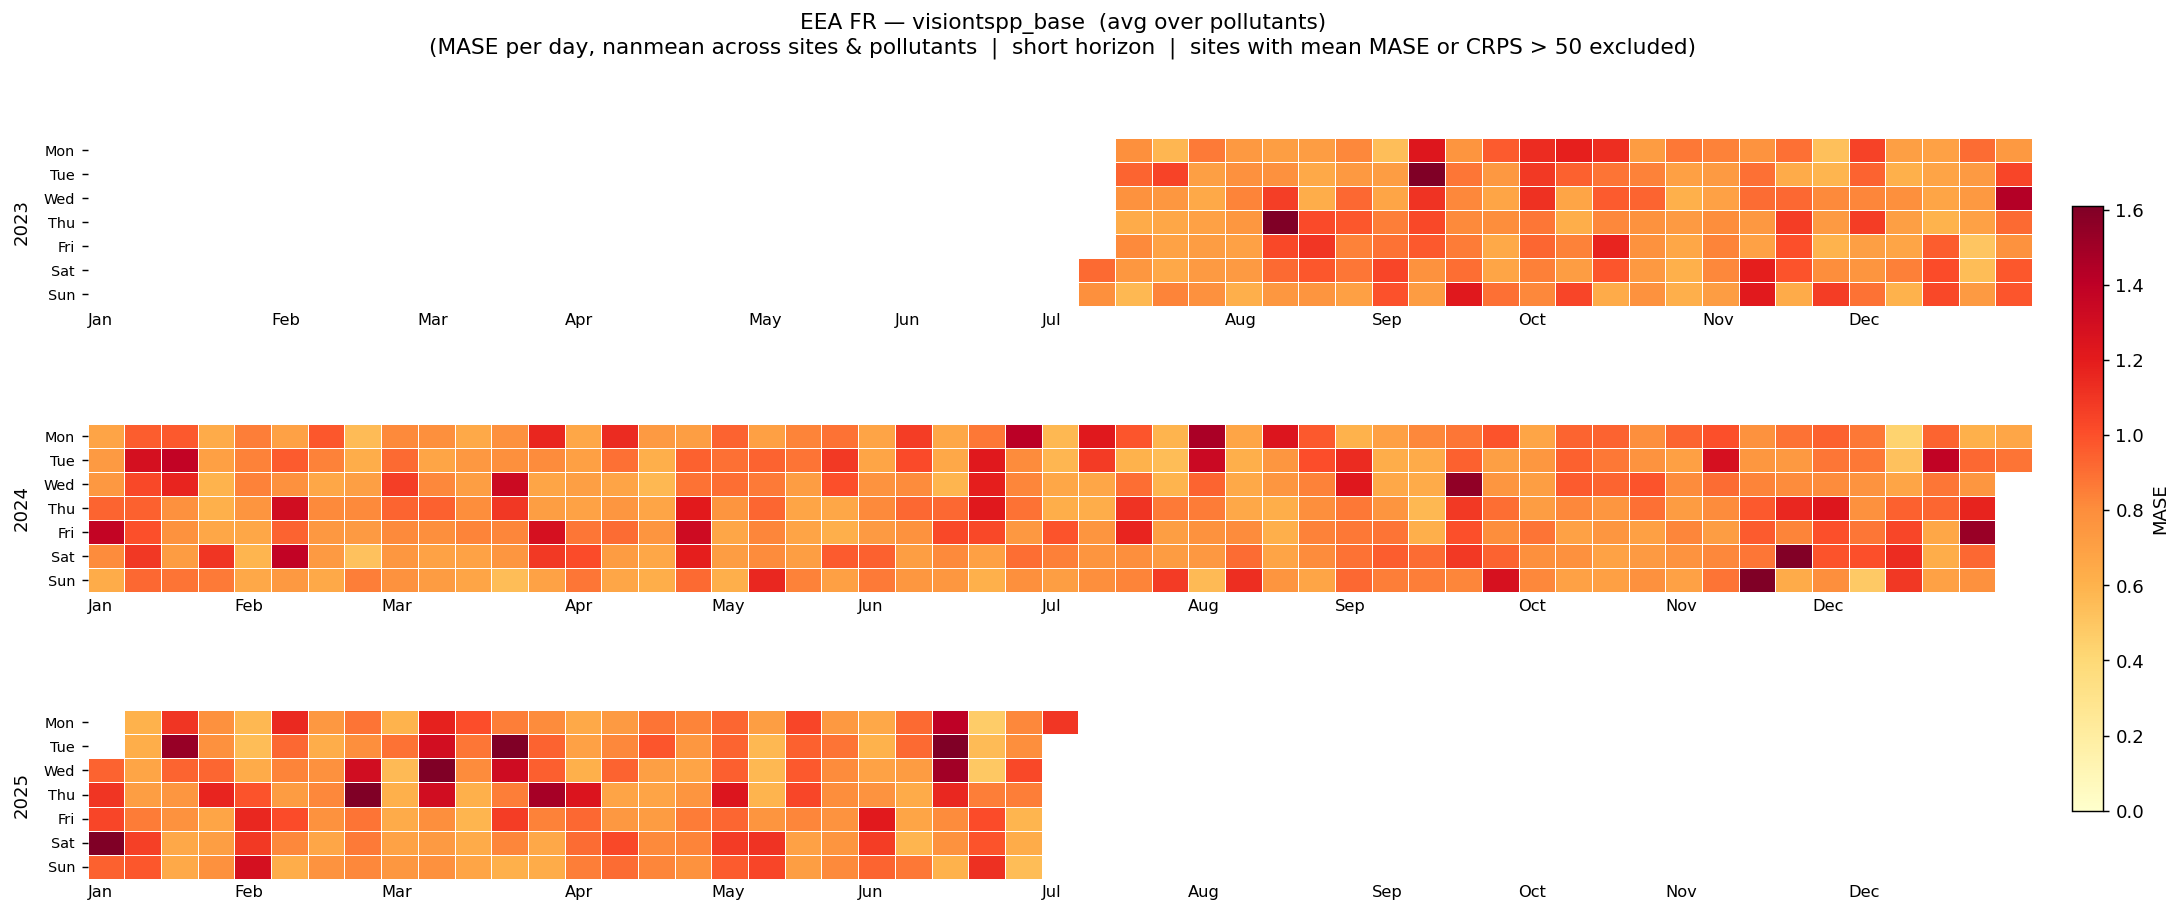

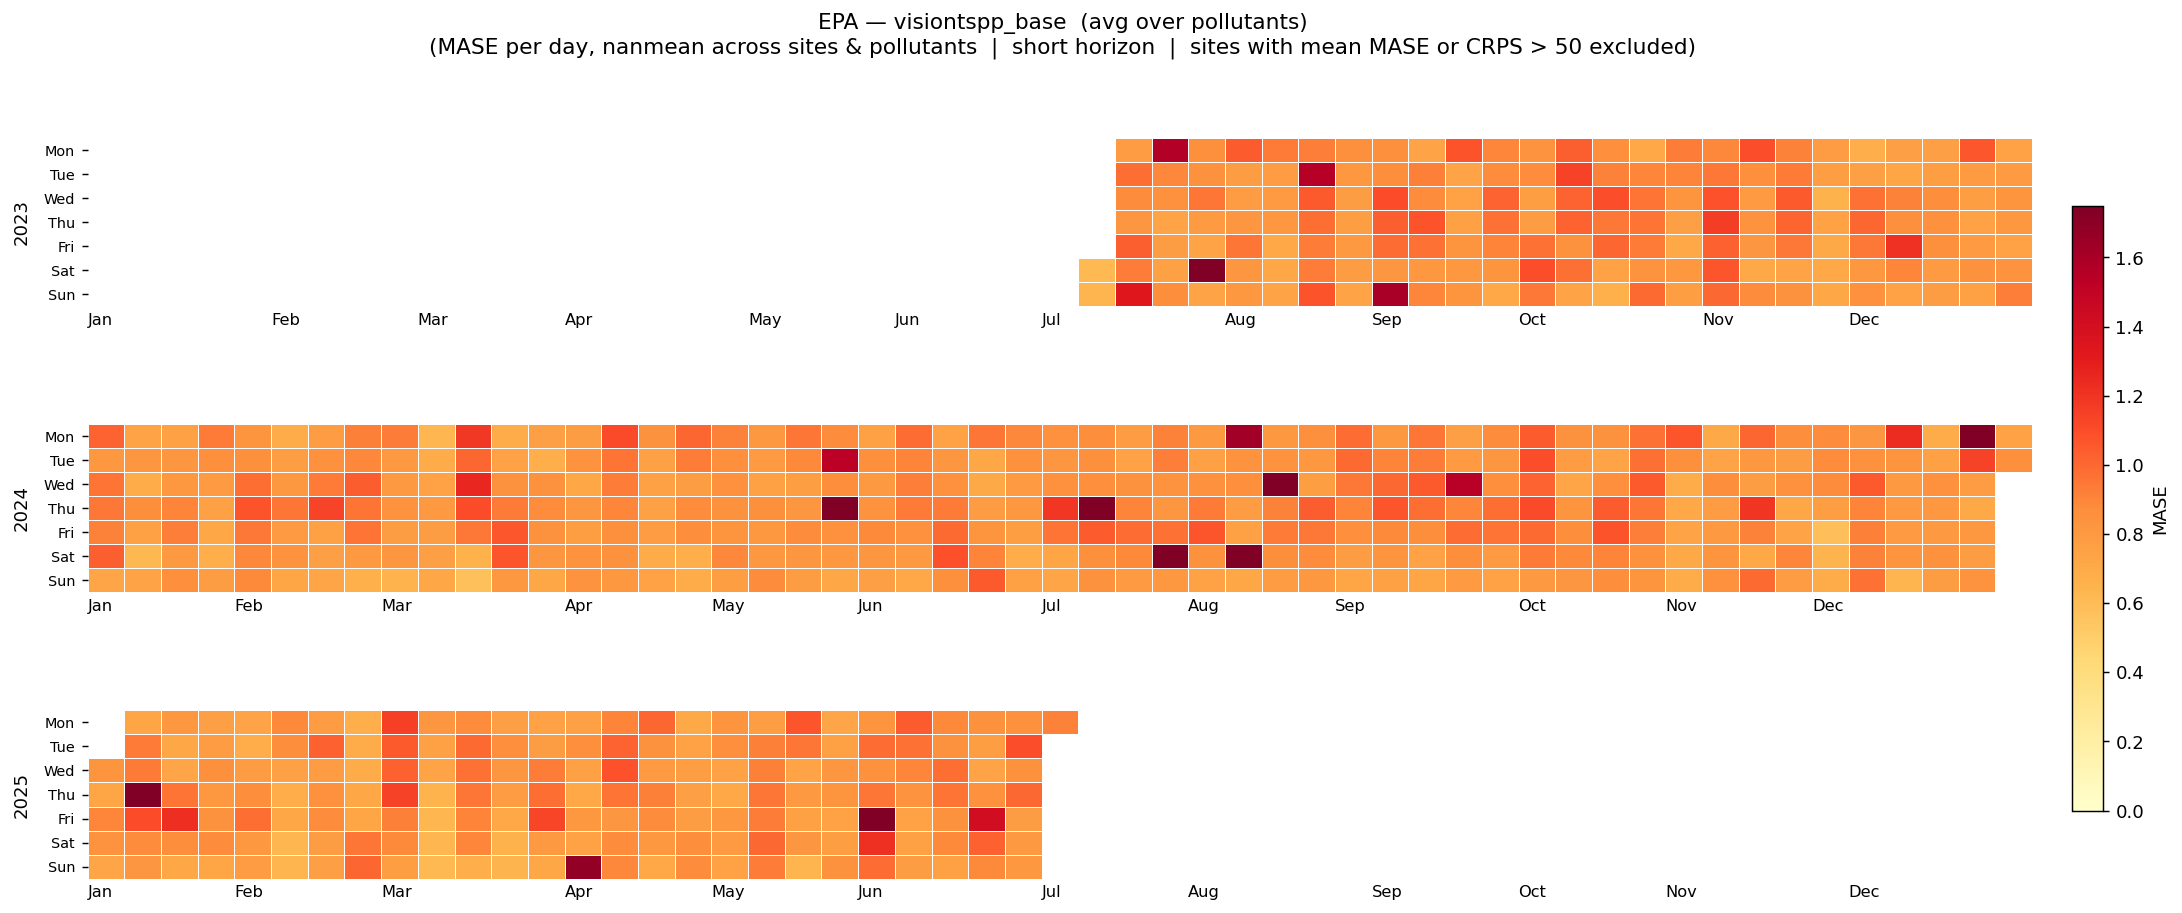

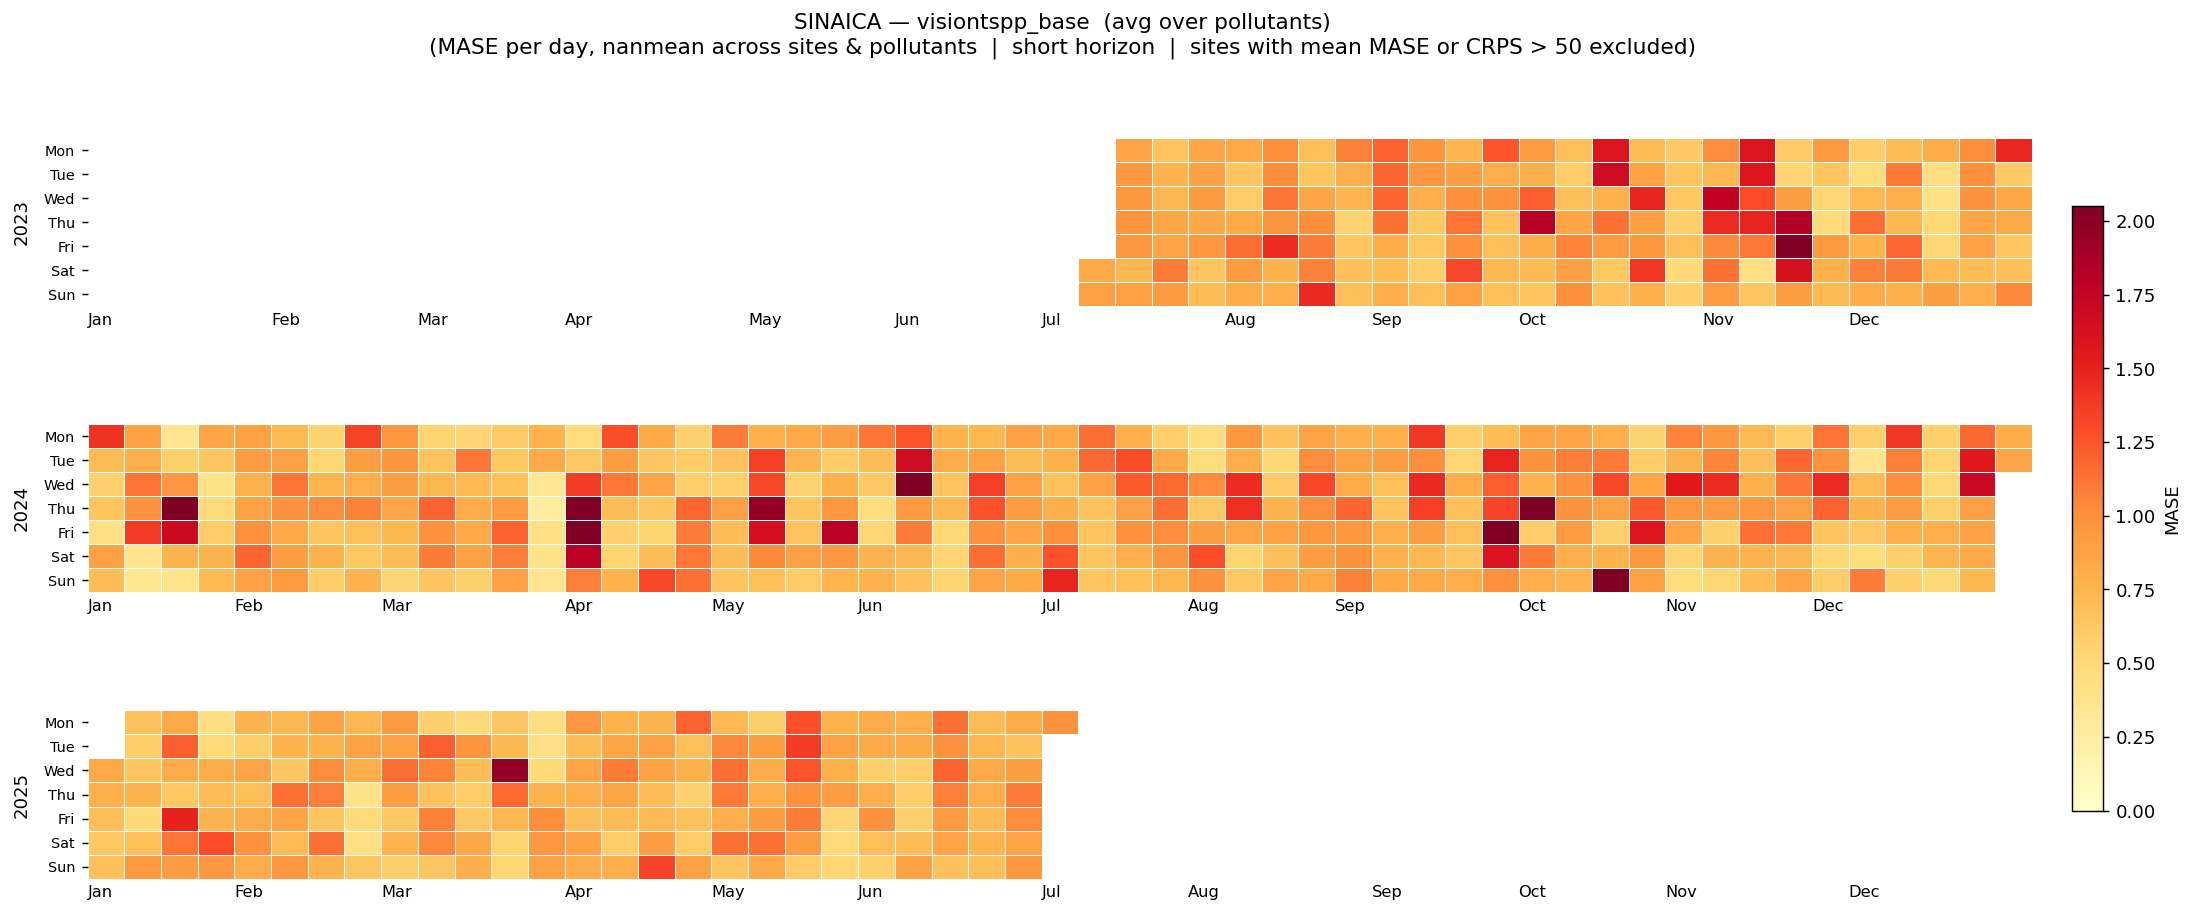

In [21]:
# ── Main loop: one calendar heatmap per (dataset × model), averaged over pollutants ──

for dataset_id in DATASETS:
    model_data = load_all_models(RESULTS_ROOT, dataset_id, HORIZON, MODELS, METRIC)
    if not model_data:
        print(f"[skip] {dataset_id} — no data for any model")
        continue

    timestamps_ref = next(
        (d["timestamps"] for d in model_data.values() if d["timestamps"] is not None),
        None,
    )
    if timestamps_ref is None:
        print(f"[skip] {dataset_id} — no timestamps found")
        continue

    pollutants = sorted({pol for d in model_data.values() for pol in d["pollutants"]})

    for model, d in model_data.items():
        # Collect per-window means for each pollutant, then average across pollutants
        pol_arrays = []
        for pollutant in pollutants:
            per_window = get_masked_mean(
                d, METRIC, pollutant, dataset_id, HORIZON, excluded_sites
            )
            if per_window is not None and not np.all(np.isnan(per_window)):
                pol_arrays.append(per_window)

        if not pol_arrays:
            continue

        # nanmean across pollutants -> (n_windows,)
        combined = np.nanmean(np.stack(pol_arrays, axis=0), axis=0)

        daily_mase = pd.Series(combined, index=timestamps_ref)
        plot_calendar_heatmap(daily_mase, dataset_id, model, metric=METRIC)